# Pruning Validation Demo

This notebook creates a synthetic CpG-like dataset with intentionally correlated feature blocks.
It is designed to stress the new redundancy-pruning modes in `MESA_modality`.

Expected behavior:
- `baseline` may keep multiple redundant features from the same correlated block.
- `score` should prefer the strongest univariate representative in each block.
- `model` may choose a different representative when single-feature CV performance differs from univariate ranking.


In [1]:
from mesa import MESA_modality
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

plt.rcParams['figure.figsize'] = (7, 5)
RNG = np.random.RandomState(7)

## Build a correlated-block dataset

Each block is driven by a latent variable. Features inside a block are highly correlated,
but have slightly different signal strengths. That gives the pruning step a real decision to make.


In [2]:
def make_block(latent, block_name, strengths, noise_scale=0.12, nonlinear=None):
    columns = {}
    for i, strength in enumerate(strengths):
        values = strength * latent + RNG.normal(scale=noise_scale, size=len(latent))
        if nonlinear == 'square' and i == len(strengths) - 1:
            values = values + 0.6 * (latent ** 2)
        if nonlinear == 'threshold' and i == len(strengths) - 2:
            values = values + 0.5 * (latent > 0).astype(float)
        columns[f'{block_name}_cpg_{i}'] = values
    return pd.DataFrame(columns)


n_samples = 240
latent_a = RNG.normal(size=n_samples)
latent_b = RNG.normal(size=n_samples)
latent_c = RNG.normal(size=n_samples)
latent_d = RNG.normal(size=n_samples)

# Binary outcome driven mostly by latent_a and latent_b, with weaker latent_c contribution.
risk = 1.8 * latent_a + 1.2 * latent_b + 0.45 * latent_c + RNG.normal(scale=0.7, size=n_samples)
y = (risk > np.median(risk)).astype(int)

block_a = make_block(latent_a, 'block_a', [1.15, 1.05, 0.98, 0.92, 0.85, 0.80, 0.76, 0.70])
block_b = make_block(latent_b, 'block_b', [1.10, 1.02, 0.95, 0.91, 0.86, 0.82, 0.78, 0.72])
block_c = make_block(latent_c, 'block_c', [0.90, 0.84, 0.80, 0.75, 0.72, 0.68, 0.63, 0.58], nonlinear='threshold')
block_d = make_block(latent_d, 'block_d', [0.65, 0.60, 0.56, 0.52, 0.49, 0.45, 0.41, 0.38], nonlinear='square')

# Add many noise features so redundant features compete for limited top_n slots.
noise = pd.DataFrame(
    RNG.normal(size=(n_samples, 60)),
    columns=[f'noise_{i}' for i in range(60)],
)

X = pd.concat([block_a, block_b, block_c, block_d, noise], axis=1)
X.index = [f'sample_{i}' for i in range(n_samples)]
X.shape


(240, 92)

In [3]:
block_columns = {
    'block_a': [c for c in X.columns if c.startswith('block_a')],
    'block_b': [c for c in X.columns if c.startswith('block_b')],
    'block_c': [c for c in X.columns if c.startswith('block_c')],
    'block_d': [c for c in X.columns if c.startswith('block_d')],
}

corr_preview = X[block_columns['block_a']].corr().round(2)
corr_preview


,block_a_cpg_0,block_a_cpg_1,block_a_cpg_2,block_a_cpg_3,block_a_cpg_4,block_a_cpg_5,block_a_cpg_6,block_a_cpg_7
block_a_cpg_0,1.00,0.99,0.99,0.99,0.98,0.98,0.98,0.98
block_a_cpg_1,0.99,1.00,0.99,0.98,0.98,0.98,0.98,0.97
block_a_cpg_2,0.99,0.99,1.00,0.98,0.98,0.98,0.98,0.98
block_a_cpg_3,0.99,0.98,0.98,1.00,0.98,0.98,0.98,0.97
block_a_cpg_4,0.98,0.98,0.98,0.98,1.00,0.98,0.98,0.97
block_a_cpg_5,0.98,0.98,0.98,0.98,0.98,1.00,0.98,0.97
block_a_cpg_6,0.98,0.98,0.98,0.98,0.98,0.98,1.00,0.97
block_a_cpg_7,0.98,0.97,0.98,0.97,0.97,0.97,0.97,1.00


## Train/test split

In [4]:
train_index, test_index, y_train, y_test = train_test_split(
    np.arange(n_samples), y, test_size=0.25, random_state=42, stratify=y
)
X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()
X_train.shape, X_test.shape


((180, 92), (60, 92))

## Compare baseline vs pruning modes

The first selector keeps a moderate candidate set, then the new redundancy-pruning stage decides
which representative to keep from each highly correlated block before Boruta runs.


In [5]:
def build_model(mode=None):
    redundancy_kwargs = {}
    if mode is not None:
        redundancy_kwargs = {
            'redundancy_pruning': mode,
            'redundancy_threshold': 0.9,
            'redundancy_method': 'pearson',
            'redundancy_estimator': LogisticRegression(random_state=0, max_iter=1000),
            'redundancy_cv': 5,
        }

    return MESA_modality(
        top_n=8,
        selector=24,
        missing=0,
        variance_threshold=0,
        normalization=False,
        classifier=LogisticRegression(random_state=0, max_iter=1000),
        boruta_estimator=RandomForestClassifier(n_estimators=100, random_state=0),
        random_state=0,
        **redundancy_kwargs,
    )


def support_block_summary(selected_names):
    summary = {}
    for block_name, columns in block_columns.items():
        chosen = [c for c in selected_names if c in columns]
        summary[block_name] = chosen
    summary['noise'] = [c for c in selected_names if c.startswith('noise_')]
    return summary


results = {}
for mode in [None, 'score', 'model']:
    label_name = 'baseline' if mode is None else mode
    model = build_model(mode)
    model.fit(X_train, y_train)
    y_pred = model.transform_predict_proba(X_test)[:, 1]
    selected_idx = model.get_support()
    selected_names = X.columns[selected_idx].tolist()
    results[label_name] = {
        'auc': roc_auc_score(y_test, y_pred),
        'selected_idx': selected_idx.tolist(),
        'selected_names': selected_names,
        'block_summary': support_block_summary(selected_names),
        'pred': y_pred,
    }

summary = pd.DataFrame({
    mode: {
        'auc': values['auc'],
        'n_selected': len(values['selected_idx']),
        'block_a_kept': len(values['block_summary']['block_a']),
        'block_b_kept': len(values['block_summary']['block_b']),
        'block_c_kept': len(values['block_summary']['block_c']),
        'block_d_kept': len(values['block_summary']['block_d']),
        'noise_kept': len(values['block_summary']['noise']),
    }
    for mode, values in results.items()
}).T
summary


,auc,n_selected,block_a_kept,block_b_kept,block_c_kept,block_d_kept,noise_kept
baseline,0.881111,8.0,8.0,0.0,0.0,0.0,0.0
score,0.954444,6.0,1.0,1.0,1.0,0.0,3.0
model,0.963333,6.0,1.0,1.0,1.0,0.0,3.0


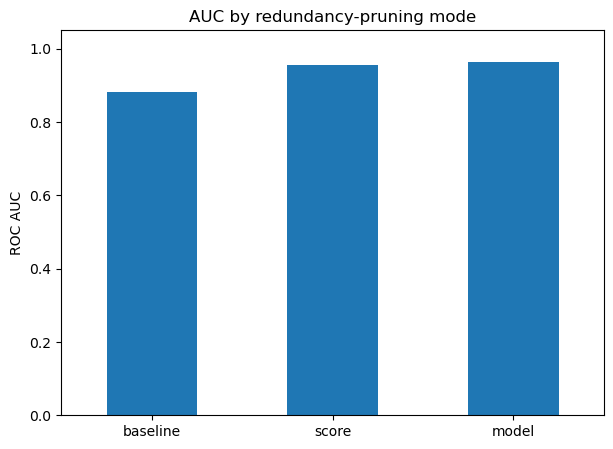

In [6]:
summary[['auc']].plot(kind='bar', legend=False)
plt.ylim(0.0, 1.05)
plt.ylabel('ROC AUC')
plt.title('AUC by redundancy-pruning mode')
plt.xticks(rotation=0)
plt.show()


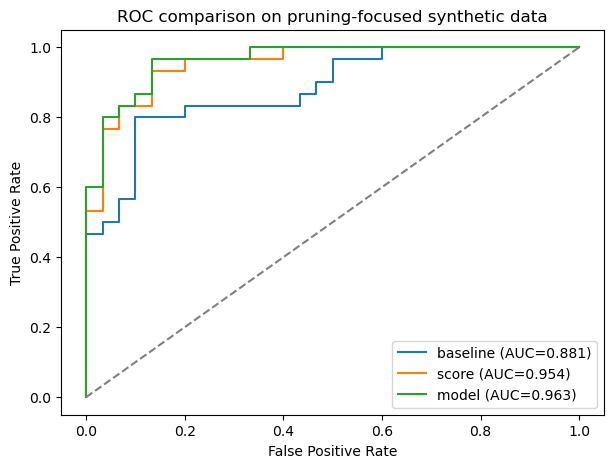

In [7]:
for mode, values in results.items():
    fpr, tpr, _ = roc_curve(y_test, values['pred'])
    plt.plot(fpr, tpr, label=f"{mode} (AUC={values['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC comparison on pruning-focused synthetic data')
plt.legend(loc=4)
plt.show()


In [8]:
for mode, values in results.items():
    print(f'\n=== {mode} ===')
    print('Selected indices:', values['selected_idx'])
    print('Selected names:', values['selected_names'])
    print('Block summary:')
    for block_name, chosen in values['block_summary'].items():
        print(f'  {block_name}: {chosen}')



=== baseline ===
Selected indices: [0, 1, 2, 3, 4, 5, 6, 7]
Selected names: ['block_a_cpg_0', 'block_a_cpg_1', 'block_a_cpg_2', 'block_a_cpg_3', 'block_a_cpg_4', 'block_a_cpg_5', 'block_a_cpg_6', 'block_a_cpg_7']
Block summary:
  block_a: ['block_a_cpg_0', 'block_a_cpg_1', 'block_a_cpg_2', 'block_a_cpg_3', 'block_a_cpg_4', 'block_a_cpg_5', 'block_a_cpg_6', 'block_a_cpg_7']
  block_b: []
  block_c: []
  block_d: []
  noise: []

=== score ===
Selected indices: [7, 13, 22, 39, 56, 91]
Selected names: ['block_a_cpg_7', 'block_b_cpg_5', 'block_c_cpg_6', 'noise_7', 'noise_24', 'noise_59']
Block summary:
  block_a: ['block_a_cpg_7']
  block_b: ['block_b_cpg_5']
  block_c: ['block_c_cpg_6']
  block_d: []
  noise: ['noise_7', 'noise_24', 'noise_59']

=== model ===
Selected indices: [7, 8, 22, 39, 56, 91]
Selected names: ['block_a_cpg_7', 'block_b_cpg_0', 'block_c_cpg_6', 'noise_7', 'noise_24', 'noise_59']
Block summary:
  block_a: ['block_a_cpg_7']
  block_b: ['block_b_cpg_0']
  block_c: ['blo

## Tuning notes

If the three modes still look too similar on your machine, try:
- lowering `redundancy_threshold` from `0.9` to `0.8`
- increasing `top_n` from `8` to `12`
- lowering `selector` from `24` to `16`
- increasing the number of features per block or reducing `noise_scale`

Those changes make correlated blocks more dominant and usually force a clearer difference between pruning modes.
